In [1]:
#Imported all Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1.Import DataBase

In [2]:
conn=sqlite3.connect("customer_churn_expanded.db")

sql_query = """ 
             SELECT name
             FROM sqlite_master
             WHERE type='table';
"""

tables = pd.read_sql(sql_query, conn)

#create dtaframe for each table
for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe:df_{table_name}")

conn.close()

Created dataframe:df_db_customer
Created dataframe:df_db_subscription
Created dataframe:df_db_support


In [3]:
# Print table names  and columns names 
conn = sqlite3.connect('customer_churn.db')

for  table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    #Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("columns:")
    print(columns["name"].tolist())
#close connection
conn.close()


Table Name: db_customer
columns:
[]

Table Name: db_subscription
columns:
[]

Table Name: db_support
columns:
[]


## 2.Data Cleaning

#### 1.First Table : df_db_customer

In [4]:
#head of customer_table
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
#tail(bottom rows) of customer_table
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
216,7773-GMBQN,rahul,India,Maharashtra,Female,1988-04-16 00:00:00,sports,None
217,1871-XKSTT,kiran,India,Tamil Nadu,Female,1989-12-21 00:00:00,movie,None
218,3292-BPNAY,kiran,India,Tamil Nadu,Male,2004-07-27 00:00:00,sports,None
219,4577-BCEUW,deepa,India,Maharashtra,Female,1977-01-22 00:00:00,drama,None
220,7392-SBPVO,rahul,India,Maharashtra,Female,1998-01-27 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  221 non-null    object
 1   name        221 non-null    object
 2   country     218 non-null    object
 3   state       221 non-null    object
 4   gender      221 non-null    object
 5   dob         221 non-null    object
 6   interests   181 non-null    object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 13.9+ KB


In [7]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

#### a. Rename Col:

In [8]:
df_db_customer.rename(columns={'name':'Employee_Name'},inplace=True)
df_db_customer

,customerid,Employee_Name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
...,...,...,...,...,...,...,...,...
216,7773-GMBQN,rahul,India,Maharashtra,Female,1988-04-16 00:00:00,sports,None
217,1871-XKSTT,kiran,India,Tamil Nadu,Female,1989-12-21 00:00:00,movie,None
218,3292-BPNAY,kiran,India,Tamil Nadu,Male,2004-07-27 00:00:00,sports,None
219,4577-BCEUW,deepa,India,Maharashtra,Female,1977-01-22 00:00:00,drama,None


#### b. drop columns:

In [9]:
#Drop columns by using INDEXING
#df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
#df_db_customer.drop(df_db_customer.columns[6:],axis=1)

#Drop columns by using Drop command simple
df_db_customer.drop(columns=['interests','pincode'],inplace=True)
df_db_customer

,customerid,Employee_Name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
...,...,...,...,...,...,...
216,7773-GMBQN,rahul,India,Maharashtra,Female,1988-04-16 00:00:00
217,1871-XKSTT,kiran,India,Tamil Nadu,Female,1989-12-21 00:00:00
218,3292-BPNAY,kiran,India,Tamil Nadu,Male,2004-07-27 00:00:00
219,4577-BCEUW,deepa,India,Maharashtra,Female,1977-01-22 00:00:00


#### c. change data type: 

In [10]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     221 non-null    object
 1   Employee_Name  221 non-null    object
 2   country        218 non-null    object
 3   state          221 non-null    object
 4   gender         221 non-null    object
 5   dob            221 non-null    object
dtypes: object(6)
memory usage: 10.5+ KB


In [11]:
df_db_customer["dob"]=pd.to_datetime(df_db_customer["dob"],format='mixed')

#### d. data standardization - Replace:

In [12]:
df_db_customer["gender"].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [13]:
df_db_customer["gender"]=df_db_customer["gender"].replace({'Men':'Male','Women':'Female'})

#### e. fix missing values (using existing data):

In [14]:
df_db_customer["country"].isna()
df_db_customer[df_db_customer["country"].isna()]

,customerid,Employee_Name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [15]:
# country and state - unique value pair

# Creating state → country map from non-null rows
State_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
State_country_mapping

# Fill the missing country using State
df_db_customer["country"]=df_db_customer["country"].fillna(df_db_customer["state"].map(State_country_mapping))
df_db_customer["country"]

0      India
1      India
2      India
3      India
4      India
       ...  
216    India
217    India
218    India
219    India
220    India
Name: country, Length: 221, dtype: object

#### 2.Second Table : db_subscription

In [16]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [17]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
216,7773-GMBQN,2025-06-07,Yearly,2026-06-07,Basic,Two Year,None,Service Issue,936.02,1255,60
217,1871-XKSTT,2022-12-12,Monthly,2023-01-11,Basic,Month-to-Month,None,Price,495.73,1302,18
218,3292-BPNAY,2025-07-06,Quarterly,2025-10-04,Premium,Month-to-Month,None,Service Issue,1542.88,780,64
219,4577-BCEUW,2019-12-23,Yearly,2020-12-22,Standard,Two Year,2021-02-01,Competitor,932.05,1138,72
220,7392-SBPVO,2022-07-28,Monthly,2022-08-27,Basic,Month-to-Month,2022-11-18,Moved,1546.37,178,85


In [18]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               221 non-null    object 
 1   subscription_start_date  221 non-null    object 
 2   subscription_type        221 non-null    object 
 3   renewal_date             221 non-null    object 
 4   plan_type                221 non-null    object 
 5   contract_type            221 non-null    object 
 6   cancellation_date        75 non-null     object 
 7   cancellation_reason      172 non-null    object 
 8   monthly_charges          221 non-null    float64
 9   cltv                     221 non-null    int64  
 10  churn_score              221 non-null    int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 19.1+ KB


#### 1.Change data type:

In [19]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col= ["subscription_start_date", "renewal_date", "cancellation_date"]

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               221 non-null    object        
 1   subscription_start_date  221 non-null    datetime64[ns]
 2   subscription_type        221 non-null    object        
 3   renewal_date             221 non-null    datetime64[ns]
 4   plan_type                221 non-null    object        
 5   contract_type            221 non-null    object        
 6   cancellation_date        75 non-null     datetime64[ns]
 7   cancellation_reason      172 non-null    object        
 8   monthly_charges          221 non-null    float64       
 9   cltv                     221 non-null    int64         
 10  churn_score              221 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 19.1+ KB


#### 2.Replace Values:

In [20]:
df_db_subscription["subscription_type"].unique()

array(['Refferal', 'Paid', 'Organic', 'Yearly', 'Quarterly', 'Monthly'],
      dtype=object)

In [21]:
df_db_subscription["subscription_type"]=df_db_subscription["subscription_type"].replace({'Yearly':'Refferal','Quarterly':'Paid','Monthly':'Organic'})

In [22]:
df_db_subscription["plan_type"].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [23]:
df_db_subscription["cancellation_reason"].unique()

array([None, 'Switched to competitor', 'Too expensive',
       'Not enough content', 'Poor streaming quality',
       'Forgot to cancel trial', 'Competitor', 'Moved', 'Service Issue',
       'Price'], dtype=object)

#### 3.Third Table : df_db_support

In [24]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
...,...,...,...,...,...,...
92,9573-FQLLU,2025-05-04 00:00:00,2,3,None,guidance to renew
93,1871-XKSTT,2025-10-11 00:00:00,0,5,None,guidance to renew
94,3292-BPNAY,2024-03-09 00:00:00,1,5,None,service issue
95,4577-BCEUW,2025-12-04 00:00:00,3,4,None,None


In [25]:
df_db_support["csat_score"]=df_db_support["csat_score"]+50

In [94]:
df_db_support.head(20)

,customerid,complaint_date,escalations,csat_score,complaint_count
13,3174-ZCMHC,2024-01-05,N,51,1
86,3837-QHETC,2024-01-09,N,52,1
2,0013-EXCHZ,2024-01-20,Y,70,1
49,9621-LNOVS,2024-02-13,N,52,1
21,6486-SZGLP,2024-02-16,Y,54,1
48,8360-LTATL,2024-02-20,Y,53,1
90,5217-YXDIZ,2024-03-02,N,53,1
94,3292-BPNAY,2024-03-09,N,55,1
12,9178-LFNHA,2024-03-11,Y,55,1
69,6532-IKDCJ,2024-03-23,N,53,1


In [27]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
92,9573-FQLLU,2025-05-04 00:00:00,2,53,None,guidance to renew
93,1871-XKSTT,2025-10-11 00:00:00,0,55,None,guidance to renew
94,3292-BPNAY,2024-03-09 00:00:00,1,55,None,service issue
95,4577-BCEUW,2025-12-04 00:00:00,3,54,None,None
96,7392-SBPVO,2024-04-02 00:00:00,2,53,None,requested callback


In [28]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      97 non-null     object
 1   complaint_date  97 non-null     object
 2   escalations     97 non-null     object
 3   csat_score      97 non-null     int64 
 4   col_1           0 non-null      object
 5   comment         78 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.7+ KB


#### Drop columns:

In [29]:
df_db_support.drop(columns=["col_1", "comment"],inplace=True)

#### Change Data Type:

In [30]:
df_db_support["complaint_date"]=pd.to_datetime(df_db_support["complaint_date"],format='mixed')
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      97 non-null     object        
 1   complaint_date  97 non-null     datetime64[ns]
 2   escalations     97 non-null     object        
 3   csat_score      97 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 3.2+ KB


#### 2.Replace Values:

In [31]:
df_db_support["escalations"].unique()

array(['N', 'Y', '1', '3', '0', '2'], dtype=object)

In [32]:
df_db_support["escalations"]=df_db_support["escalations"].replace({'1':'N','3':'Y','0':'N','2':'Y'})
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,110
1,0003-MKNFE,2024-08-28,Y,60
2,0013-EXCHZ,2024-01-20,Y,70
3,0013-MHZWF,2025-03-18,N,140
4,0013-SMEOE,2024-11-01,N,80
...,...,...,...,...
92,9573-FQLLU,2025-05-04,Y,53
93,1871-XKSTT,2025-10-11,N,55
94,3292-BPNAY,2024-03-09,N,55
95,4577-BCEUW,2025-12-04,Y,54


## 3. Feature Engineering & Data Analysis

#### Create New Column:

In [33]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['Churn_Flag']=np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,Churn_Flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
...,...,...,...,...,...,...,...,...,...,...,...,...
216,7773-GMBQN,2025-06-07,Refferal,2026-06-07,Basic,Two Year,NaT,Service Issue,936.02,1255,60,0
217,1871-XKSTT,2022-12-12,Organic,2023-01-11,Basic,Month-to-Month,NaT,Price,495.73,1302,18,0
218,3292-BPNAY,2025-07-06,Paid,2025-10-04,Premium,Month-to-Month,NaT,Service Issue,1542.88,780,64,0
219,4577-BCEUW,2019-12-23,Refferal,2020-12-22,Standard,Two Year,2021-02-01,Competitor,932.05,1138,72,1


#### Merge Dataframes (join):

In [34]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after
df=(df_db_subscription
                      .merge(df_db_customer, on = 'customerid', how='left')
                      .merge(df_db_support, on = 'customerid', how='left')
   )

In [35]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,Churn_Flag,Employee_Name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,110.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,60.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,7773-GMBQN,2025-06-07,Refferal,2026-06-07,Basic,Two Year,NaT,Service Issue,936.02,1255,60,0,rahul,India,Maharashtra,Female,1988-04-16,NaT,NaN,NaN
219,1871-XKSTT,2022-12-12,Organic,2023-01-11,Basic,Month-to-Month,NaT,Price,495.73,1302,18,0,kiran,India,Tamil Nadu,Female,1989-12-21,2025-10-11,N,55.0
220,3292-BPNAY,2025-07-06,Paid,2025-10-04,Premium,Month-to-Month,NaT,Service Issue,1542.88,780,64,0,kiran,India,Tamil Nadu,Male,2004-07-27,2024-03-09,N,55.0
221,4577-BCEUW,2019-12-23,Refferal,2020-12-22,Standard,Two Year,2021-02-01,Competitor,932.05,1138,72,1,deepa,India,Maharashtra,Female,1977-01-22,2025-12-04,Y,54.0


In [36]:
df.shape

(223, 20)

In [37]:
df_db_subscription.shape

(221, 12)

In [38]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 221
df_db_customer unique value: 221
df_db_support unique value: 95
df_db_support all value: 97


In [39]:
df_db_support.shape

(97, 4)

In [40]:
df_db_support["customerid"].nunique()

95

In [41]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,110
1,0003-MKNFE,2024-08-28,Y,60
2,0013-EXCHZ,2024-01-20,Y,70
3,0013-MHZWF,2025-03-18,N,140
4,0013-SMEOE,2024-11-01,N,80
...,...,...,...,...
92,9573-FQLLU,2025-05-04,Y,53
93,1871-XKSTT,2025-10-11,N,55
94,3292-BPNAY,2024-03-09,N,55
95,4577-BCEUW,2025-12-04,Y,54


In [42]:
df_db_support["complaint_count"]=df_db_support.groupby("customerid")["customerid"].transform('count')

In [43]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,110,2
1,0003-MKNFE,2024-08-28,Y,60,2
2,0013-EXCHZ,2024-01-20,Y,70,1
3,0013-MHZWF,2025-03-18,N,140,1
4,0013-SMEOE,2024-11-01,N,80,1
...,...,...,...,...,...
92,9573-FQLLU,2025-05-04,Y,53,1
93,1871-XKSTT,2025-10-11,N,55,1
94,3292-BPNAY,2024-03-09,N,55,1
95,4577-BCEUW,2025-12-04,Y,54,1


In [44]:
df_db_support['escalations'].unique()

array(['N', 'Y'], dtype=object)

In [45]:
df_db_support['escalations']=df_db_support['escalations'].replace({'No':'N','Yes':'Y'})

In [46]:
df_db_support=df_db_support.sort_values("complaint_date").drop_duplicates("customerid",keep='last')

In [47]:
df_db_support['customerid'].size

95

In [48]:
#Now Merge
df=(df_db_subscription
                      .merge(df_db_customer, on = 'customerid', how='left')
                      .merge(df_db_support, on = 'customerid', how='left')
   )

In [49]:
df.shape

(221, 21)

#### Export Dataframe

In [50]:
df.to_csv('exported_churn_data.csv',index=False)

# Data Analysis:

#### 1.Churn Rate:

In [51]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn_Flag', 'Employee_Name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [52]:
churn_rate=df['Churn_Flag'].mean()*100
print('churn Rate',round(churn_rate,2),"%")

churn Rate 33.94 %


#### 2.Retation Rate:

In [53]:
retation_rate=100-churn_rate
print('retation_rate',round(retation_rate,2),"%")

retation_rate 66.06 %


#### 3.Churn by plan type:

In [54]:
churn_by_plan=(df.groupby('plan_type')['Churn_Flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           30.77
1   Premium           30.00
2  Standard           41.10


#### 4 a. Churn by state + sum(revenue) & count of users  

In [55]:
churn_by_state=df.groupby("state").agg({"monthly_charges":"sum", "customerid":"count"})
churn_by_state

,monthly_charges,customerid
state,,
Delhi,31880.61,35
Gujarat,35769.40,33
Karnataka,26426.76,29
Kathmandu,20.98,2
Maharashtra,44064.17,40
Meghalaya,42.97,3
Nagaland,22.99,1
Rajasthan,36.98,2
Tamil Nadu,41111.79,42


####  4 b. Churn by subscription type + sum(revenue) & count of users   

In [56]:
Churn_by_subscription_type=df.groupby("subscription_type").agg({"monthly_charges":"sum", "customerid":"count"})
Churn_by_subscription_type

,monthly_charges,customerid
subscription_type,,
Organic,71623.99,75
Paid,70145.53,70
Refferal,71648.80,76


#### 5.ARPU - AVG Revenue per user

In [57]:
arpu = df['monthly_charges'].mean()
print('ARPU',round(arpu,2))

ARPU 965.69


#### 6. Avg Customer Tenure

In [58]:
# count of days users has used our service : cancellation date else current date
today=pd.Timestamp.today()

df['tenure_days']=np.where(
             df['cancellation_date'].notna(),
      (df["cancellation_date"] - df["subscription_start_date"]).dt.days,
    (today - df["subscription_start_date"]).dt.days
)

avg_tenure = df["tenure_days"].mean()
print("AVG Tenure (Days) = ",round(avg_tenure),0)

AVG Tenure (Days) =  1079 0


#### calculate customer age

In [59]:
today=pd.Timestamp.today()
customer_age=(today-df["dob"]).dt.days
customer_age

0      16178
1      11205
2      17695
3       9098
4      13233
       ...  
216    13982
217    13368
218     8036
219    18084
220    10409
Name: dob, Length: 221, dtype: int64

In [60]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn_Flag', 'Employee_Name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

#### 7.Revenue at Risk - revenue lost from churned users

In [61]:
revenue_at_risk=df.loc[df["Churn_Flag"]==1,'monthly_charges'].sum().round(2)
print("Revenue at Risk (RS 'K')=",revenue_at_risk)

Revenue at Risk (RS 'K')= 72769.97


#### 8.Esclation Rate

In [62]:
escalation_rate=(df['escalations']=='Y').mean()*100
print('escalation_rate',round(escalation_rate,2),"%")

escalation_rate 25.79 %


#### 9.Avg Complaint Rate

In [63]:
avg_complaints = df["complaint_count"].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.44


#### 10.Correlation  escalations vs churn 

In [64]:
df["escalations"]=np.where(df["escalations"]=="Y",1,0)  # Encoding string to  int type
corr_df = df[["escalations","Churn_Flag"]].dropna()

correlation=corr_df["escalations"].corr(df["Churn_Flag"])
print("Correlation Between esclation VS churn is = ",round(correlation,2))

Correlation Between esclation VS churn is =  0.08


In [65]:
# correlation=df["escalations"].corr(df["Churn_Flag"]).round(2)
# correlation

#### 11.Create a column using existing column- Churn Risk

In [66]:
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

In [67]:
df[["churn_score","churn_risk"]].tail()

,churn_score,churn_risk
216,60,med
217,18,low
218,64,med
219,72,high
220,85,high


#### 12.Total Revenue:

In [68]:
Revenue=df["monthly_charges"].sum()
Revenue

213418.32

## 4. Visualization using Matplotlib:

In [69]:
#Best practice to create a copy thenwork on it  
df_visual=df.copy()

In [70]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn_Flag', 'Employee_Name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

#### 4.1 Yearly Churn Trend(Time Series  KPI)

In [71]:
df_visual["Year"]=df_visual['cancellation_date'].dt.year

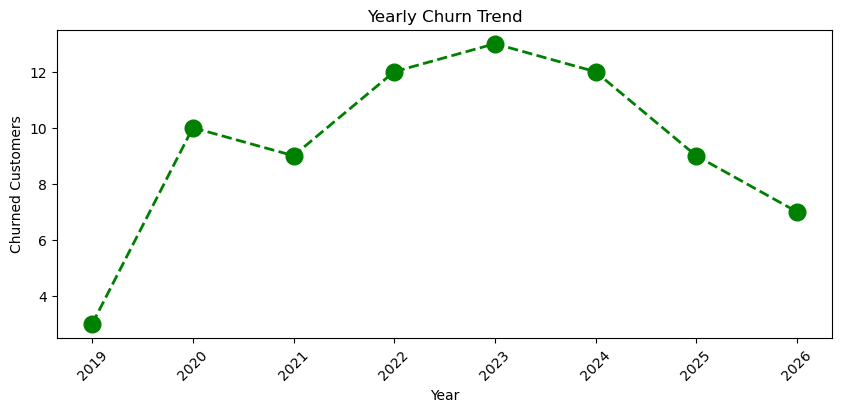

In [72]:
df_visual['Year']=df_visual['cancellation_date'].dt.to_period('Y')
churn_trend = df_visual[df_visual['Churn_Flag']== 1].groupby('Year').size()

plt.figure(figsize=(10,4))
plt.plot(churn_trend.index.astype(str),churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title("Yearly Churn Trend")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.ylabel("Churned Customers")
plt.show()

In [73]:
df_visual

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,Year
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1961.0,low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,60.0,2.0,1501.0,high,2024
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1346.0,low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2636.0,low,NaT
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,70.0,1.0,419.0,high,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,7773-GMBQN,2025-06-07,Refferal,2026-06-07,Basic,Two Year,NaT,Service Issue,936.02,1255,...,Maharashtra,Female,1988-04-16,NaT,0,NaN,NaN,416.0,med,NaT
217,1871-XKSTT,2022-12-12,Organic,2023-01-11,Basic,Month-to-Month,NaT,Price,495.73,1302,...,Tamil Nadu,Female,1989-12-21,2025-10-11,0,55.0,1.0,1324.0,low,NaT
218,3292-BPNAY,2025-07-06,Paid,2025-10-04,Premium,Month-to-Month,NaT,Service Issue,1542.88,780,...,Tamil Nadu,Male,2004-07-27,2024-03-09,0,55.0,1.0,387.0,med,NaT
219,4577-BCEUW,2019-12-23,Refferal,2020-12-22,Standard,Two Year,2021-02-01,Competitor,932.05,1138,...,Maharashtra,Female,1977-01-22,2025-12-04,1,54.0,1.0,406.0,high,2021


#### 4.2 CLTV (Customer Lifetime Value) by ContractType 

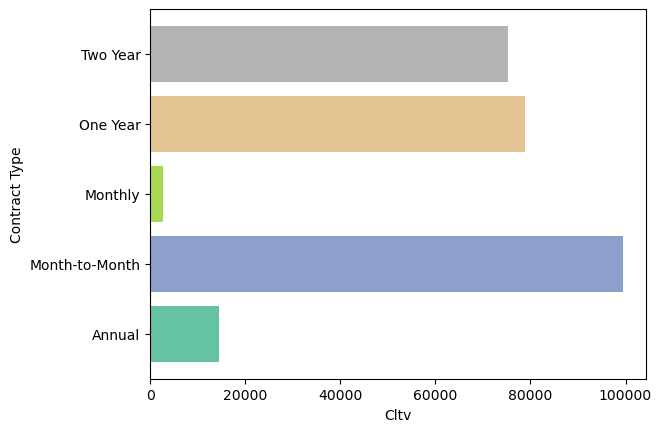

In [74]:
cltv=df.groupby('contract_type')['cltv'].sum()
cltv
colors=plt.cm.Set2(np.linspace(0,1,len(cltv))) 

plt.barh(cltv.index,cltv.values, color=colors)
plt.xlabel("Cltv")
plt.ylabel("Contract Type")
plt.show()

#### 4.3 Churn Rate By plan Type

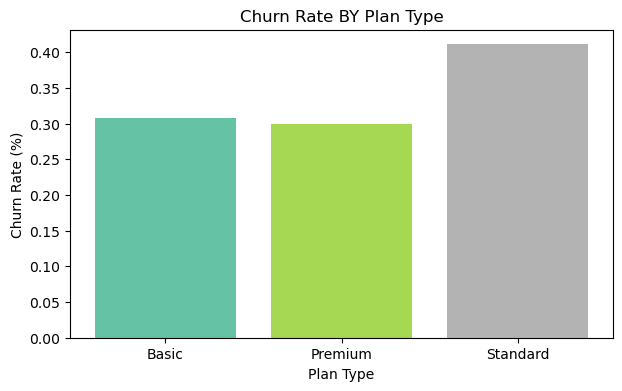

In [75]:
churn_plan= df_visual.groupby('plan_type')['Churn_Flag'].mean()

#For adding multiple colors
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))      #it is like hue in seaborn

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values, color=colors)
plt.title("Churn Rate BY Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")
plt.show()

#### 4.4 Churn By States

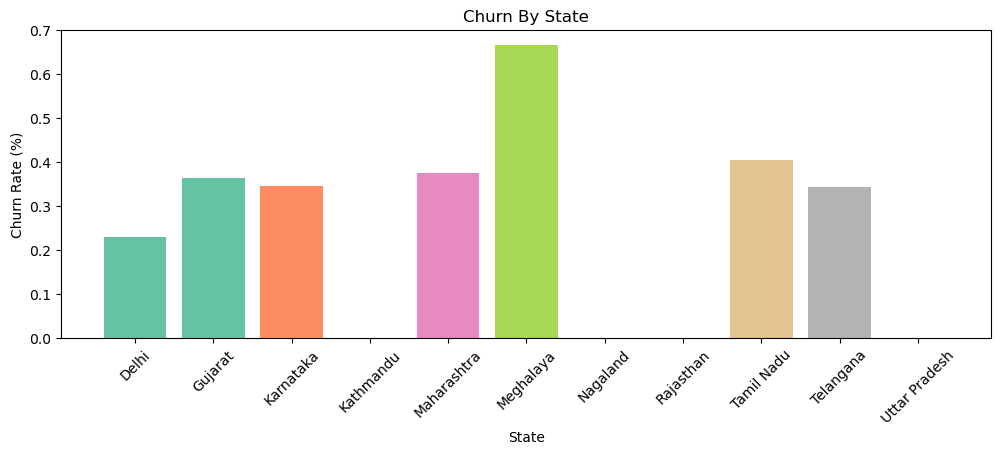

In [76]:
churn_plan=df_visual.groupby("state")["Churn_Flag"].mean()

# For adding colors
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values, color=colors)
plt.title("Churn By State")
plt.xlabel("State")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [77]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn_Flag', 'Employee_Name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'Year'],
      dtype='object')

## 5.Visualization using Seaborn:

#### 1.Heatmap (correlation Matrix):

In [78]:
# encoding - convert str to numeric so that we can find corr between features

In [79]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn_Flag', 'Employee_Name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'Year'],
      dtype='object')

In [80]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'gender','country','Churn_Flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,gender,country,Churn_Flag,churn_risk,escalations
0,Standard,Annual,12,Male,India,0,low,0
1,Premium,Annual,91,Male,India,1,high,1
2,Basic,Monthly,34,Female,India,0,low,0
3,Premium,Annual,8,Male,India,0,low,0
4,Standard,Monthly,88,Female,India,1,high,1


In [81]:
import warnings
warnings.filterwarnings("ignore")

In [82]:
#Incorrect method of encoding = as numbers are not assigned based on priority
df_encoded=df_visual[['plan_type', 'contract_type', 'churn_score', 'gender','country','Churn_Flag', 'churn_risk', 'escalations']]

categorical_cols= ['plan_type','contract_type','gender','country','churn_risk']

for col in categorical_cols:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes

<Axes: >

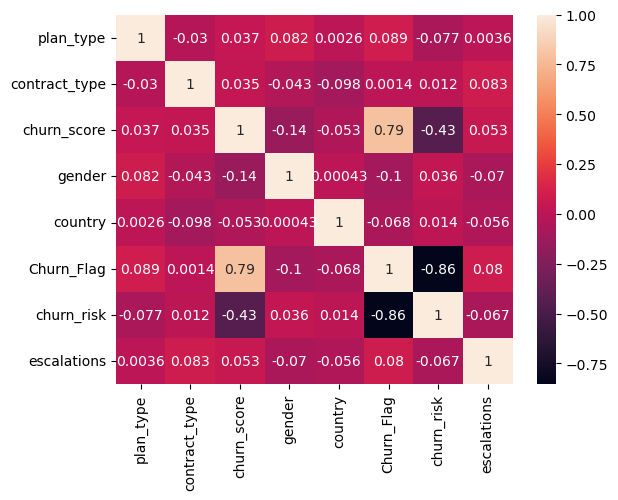

In [83]:
#heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

In [84]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('gender:', df_visual['gender'].unique())
print('country:', df_visual['country'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : ['Standard' 'Premium' 'Basic']
contract_type : ['Annual' 'Monthly' 'One Year' 'Month-to-Month' 'Two Year']
gender: ['Male' 'Female']
country: ['India' 'Nepal']
churn_risk : ['low' 'high' 'med']


In [85]:
# Correct method of Encoding - based on priority
df_encoded=df_visual[['plan_type', 'contract_type', 'churn_score', 'gender','country','Churn_Flag', 'churn_risk', 'escalations']]

order_mapping={
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type':['Monthly', 'Annual'],
    'gender':['Female', 'Male'],
    'country':['Nepal','India'],
    'churn_risk':['low', 'med', 'high']
}

for col,order in order_mapping.items():
    df_encoded[col]= pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [86]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'gender','country','Churn_Flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,gender,country,Churn_Flag,churn_risk,escalations
0,Standard,Annual,12,Male,India,0,low,0
1,Premium,Annual,91,Male,India,1,high,1
2,Basic,Monthly,34,Female,India,0,low,0
3,Premium,Annual,8,Male,India,0,low,0
4,Standard,Monthly,88,Female,India,1,high,1


In [87]:
df_encoded.head()

,plan_type,contract_type,churn_score,gender,country,Churn_Flag,churn_risk,escalations
0,1,1,12,1,1,0,0,0
1,2,1,91,1,1,1,2,1
2,0,0,34,0,1,0,0,0
3,2,1,8,1,1,0,0,0
4,1,0,88,0,1,1,2,1


#### Heatamp (correlation Matrix)

<Axes: >

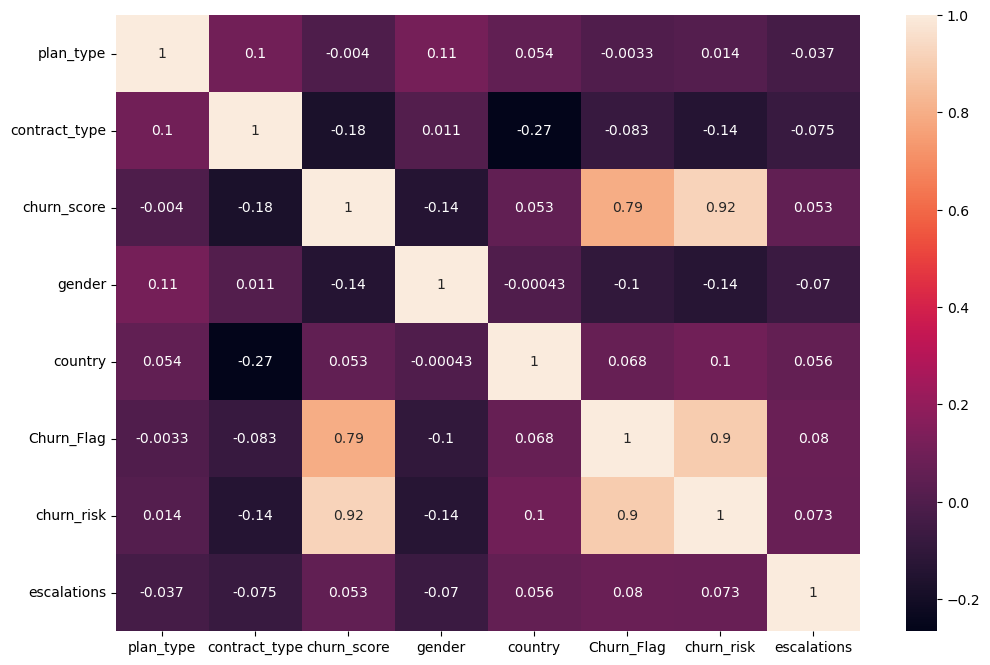

In [88]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df_encoded.corr(), annot=True)

#### 2.Pairplot - plot pairwise Relationships in a dataset:

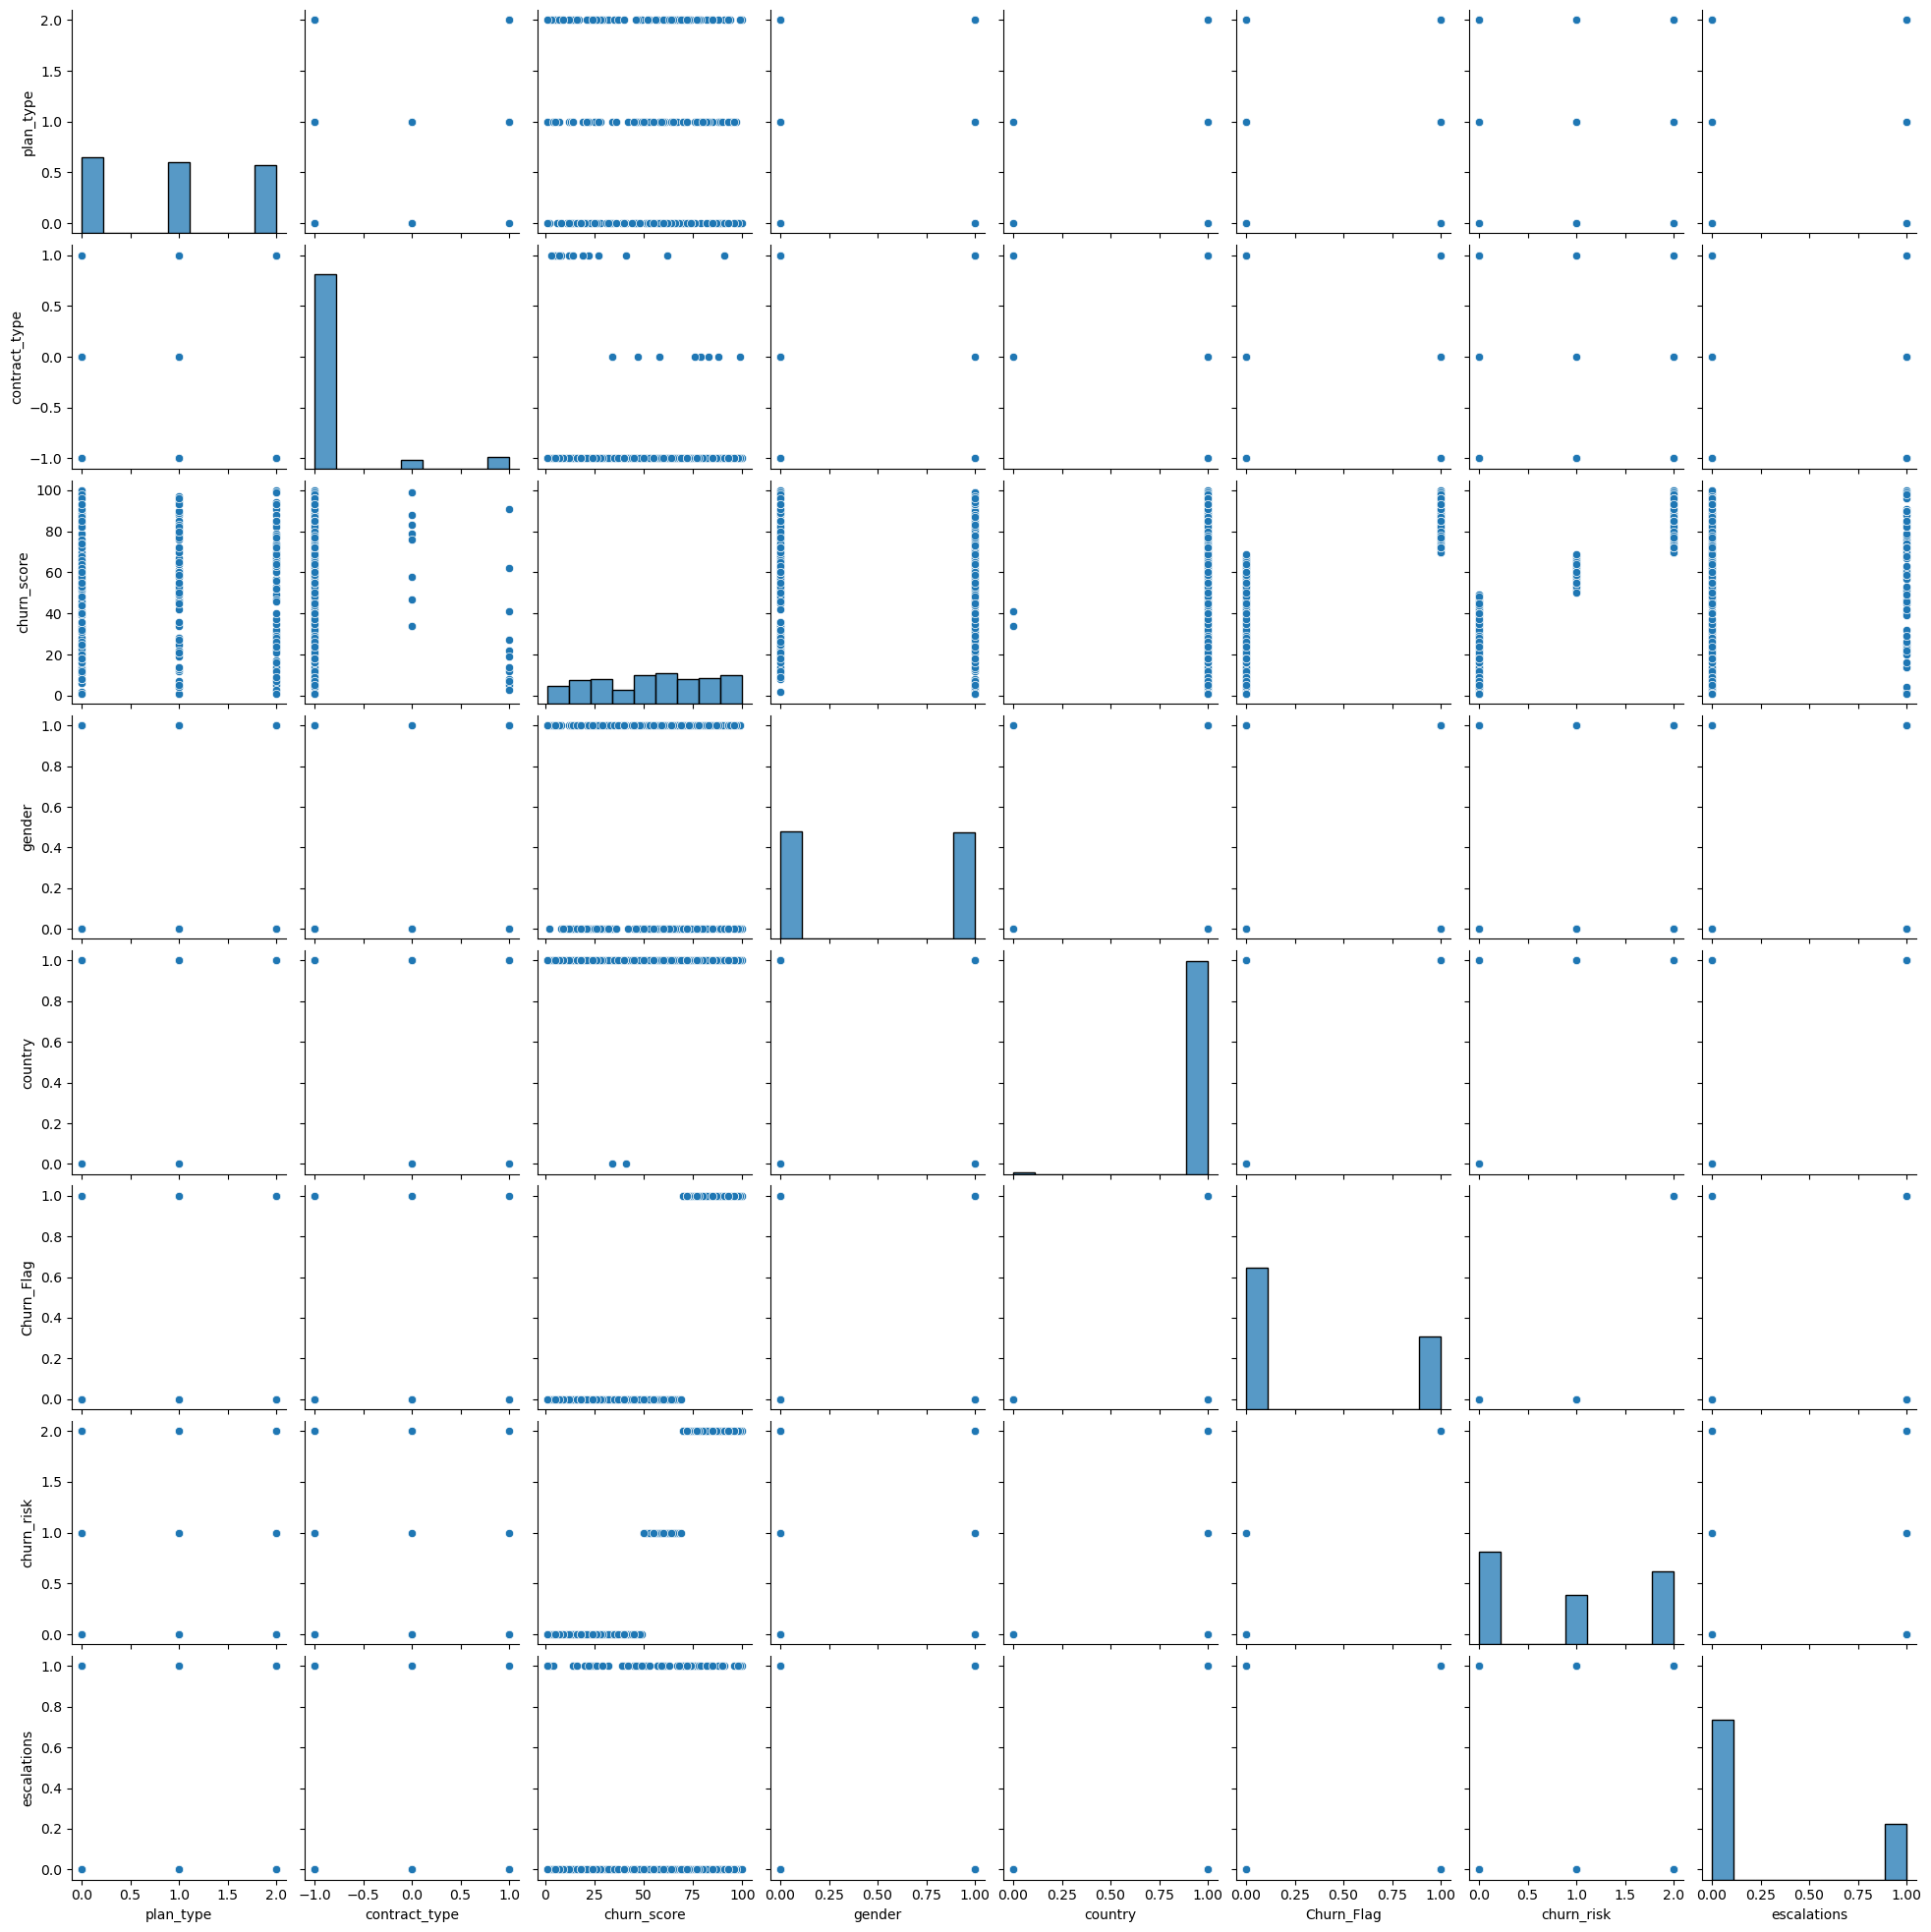

In [89]:
sns.pairplot(df_encoded)

In [90]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn_Flag', 'Employee_Name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'Year'],
      dtype='object')

#### 3.catplot/facegrid plot - multi-dim comparison 

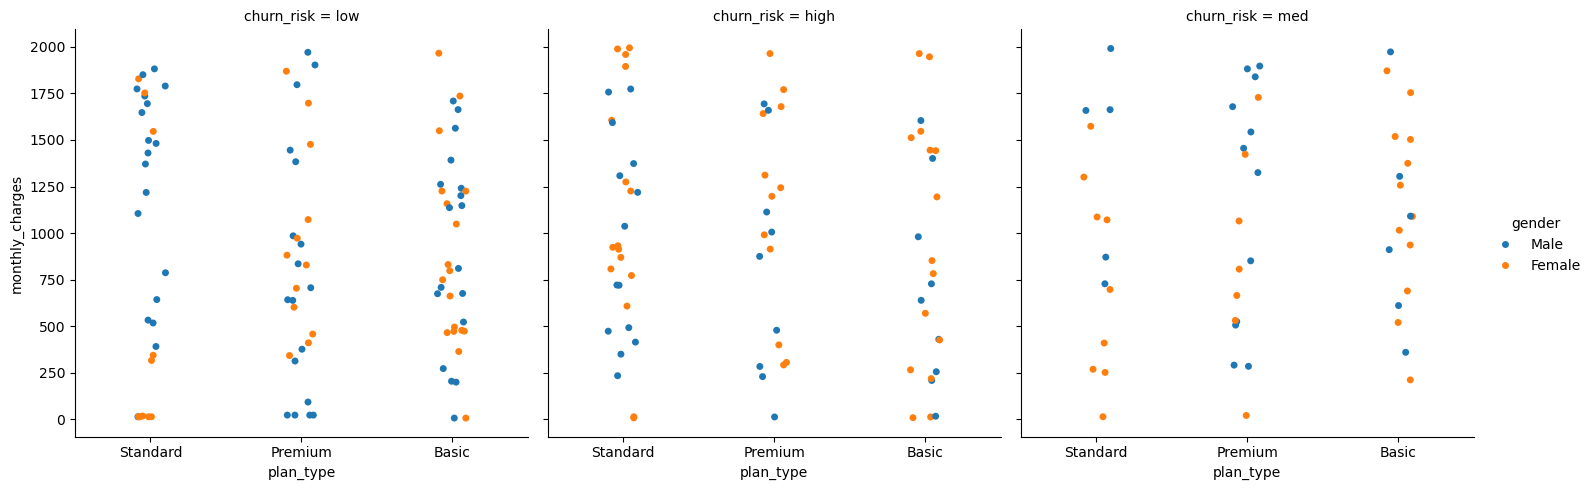

In [91]:
sns.catplot(data=df_visual,x='plan_type',y='monthly_charges',hue='gender',col='churn_risk')
 #Kind="bar,scatter...... you can change the chart"

## 6.Pivot Tables:

In [92]:
pd.pivot_table(df_visual,index="plan_type", values="Churn_Flag",aggfunc="mean")

,Churn_Flag
plan_type,
Basic,0.307692
Premium,0.300000
Standard,0.410959


In [93]:
# pivot table using multiple cols and agg type

pd.pivot_table(df_visual, index="plan_type", values=["monthly_charges","customerid", "Churn_Flag"],
               aggfunc={
                   "monthly_charges":"sum",
                   "customerid":"nunique",
                   "Churn_Flag":"mean"
               }                        
              )

,Churn_Flag,customerid,monthly_charges
plan_type,,,
Basic,0.307692,78,72538.16
Premium,0.300000,70,66815.05
Standard,0.410959,73,74065.11


# Project Completed :)